# PEAS description
##3 Performance Measures
- Battery Usage
- Area Covered
- Time Taken
- It might be the case that some of these performance measures are redundant.

### Environment
- Other drones
- Obstacles of various shapes
- Wind (Probably a time-varying 2D vector field)
The environment is continuous, dynamic and stochastic.

### Actuators
- Ability to add and subtract from the force vectors the drone is generating. Or more simply, the ability to add and subtract from the drone's position and velocity vectors.
- Ability to send messages to other drones.
### Sensors
- LIDAR
- Ability to receive messages from other drones.

# Creating a Custom VMAS Environment
To make a custom VMAS environment, the following methods are necessary to implement:
- `make_world`: Defines entities that make up the world.
- `reset_world_at`: Sets the initial conditions of the entities.
- `reward`: Defines the reward of each agents after an action.
- `observation`: Defines the observations of each agent.

Optional methods are:
- `extra_render`: Can be used for rendering custom things.
- `info`: Can be used to return useful logging info.
- `done`: For defining when an environment is done. By default, the environment is done after `max_steps`.
- `pre_step`: to perform any computation that has to happen before the simulation step.
- `post_step`: to perform any computation that has to happen after the simulation step.

More information can be found at: [Setting Up a Custom VMAS Scenario](https://colab.research.google.com/github/proroklab/VectorizedMultiAgentSimulator/blob/main/notebooks/Simulation_and_training_in_VMAS_and_BenchMARL.ipynb)
![vmas_diagram](https://raw.githubusercontent.com/matteobettini/vmas-media/refs/heads/main/media/VMAS_diagram.png)

## Downloading Dependencies

In [1]:
!pip install vmas imageio

In [2]:
!sudo apt-get update
!sudo apt-get install python3-opengl xvfb
!pip install pyvirtualdisplay
import pyvirtualdisplay
display = pyvirtualdisplay.Display(visible=False, size=(1400, 900))
display.start()

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,442 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,615 kB]
Fetched 6,189 kB in 4s (1,569 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to prov

## Imports

In [3]:
from typing import Optional, Union, List
import time
import math

import torch
from vmas.simulator.core import Agent, Landmark, World, Box, Sphere
from vmas.simulator.scenario import BaseScenario
from vmas.simulator.utils import Color
from vmas.simulator.sensors import Lidar
from vmas import make_env
from vmas.simulator.utils import ScenarioUtils
from vmas.simulator import rendering
from vmas.simulator.rendering import Geom

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Scenario Declaration

In [4]:
class WindNavScenario(BaseScenario):

    def make_world(self, batch_dim: int, device: torch.device, **kwargs) -> World:
        raise NotImplementedError()

    def reset_world_at(self, env_index: Optional[int] = None) -> None:
        raise NotImplementedError()

    # Maybe this should not be part of the class?
    # It is used to calculate the wind force at a position(s)
    def get_wind_force(self, pos: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError()

    def process_action(self, agent: Agent) -> None:
        raise NotImplementedError()

    def observation(self, agent: Agent) -> torch.Tensor:
        raise NotImplementedError()

    def reward(self, agent: Agent) -> torch.Tensor:
        raise NotImplementedError()

    def extra_render(self, env_index: int = 0) -> List[Geom]:
        raise NotImplementedError()

## Scenario Method Implementations

In [5]:
def make_world(self, batch_dim: int, device: torch.device, **kwargs) -> World:
    # initialize world
    world = World(
        dim_c=0, # Number of communication channels if any
        substeps=1,
        batch_dim=batch_dim,
        device=device,
        **kwargs
    )

    self.num_agents = kwargs.pop("num_agents", 3)
    self.agent_radius = kwargs.pop("agent_radius", 0.1)
    self.lidar_range = kwargs.pop("lidar_range", 0.3)  # Range of the LIDAR sensor
    self.n_lidar_rays = kwargs.pop(
        "n_lidar_rays", 8
    )  # Number of LIDAR rays around the agent, each ray gives an observation between 0 and lidar_range

    self.max_battery = kwargs.pop("max_battery", 100)
    self.battery_decay_coeff = kwargs.pop("battery_decay_coeff", 10)

    self.num_obstacles = kwargs.pop("num_obstacles", 10)

    # X-coordinate limit for entities spawning
    self.world_spawning_x = kwargs.pop("world_spawning_x", 1)
    # Y-coordinate limit for entities spawning
    self.world_spawning_y = kwargs.pop("world_spawning_y", 1)

    self.min_distance_between_entities = (
        self.agent_radius * 2 + 0.05
    )  # Minimum distance between entities at spawning time
    self.min_collision_distance = (
        0.005  # Minimum distance between entities for collision trigger
    )

    ScenarioUtils.check_kwargs_consumed(kwargs) # Warn if not all kwargs have been consumed

    # initialize goal(s)
    # Single goal for now
    goal = Landmark(
        name="goal",
        collide=False,
        movable=False,
        shape=Sphere(radius=0.05),
        color=Color.GREEN,
    )
    world.add_landmark(goal)

    # initialize agents
    for i in range(self.num_agents):
        sensors = [
            Lidar(
                    world,
                    n_rays=self.n_lidar_rays,
                    max_range=self.lidar_range,
                    entity_filter=lambda e: isinstance(
                        e, Agent
                    ),  # This makes sure that this lidar only percieves other agents
                    angle_start=0.0,  # LIDAR angular ranges (we sense 360 degrees)
                    angle_end=2
                    * torch.pi,  # LIDAR angular ranges (we sense 360 degrees)
                    render=True,
                    render_color=Color.BLACK
                )
            ]  # Agent LIDAR sensor

        agent = Agent(
            name=f"agent_{i}",
            collide=True,
            sensors=sensors, # give agent the sensors
            render_action=True,
            shape=Sphere(radius=self.agent_radius),
            color=Color.BLUE,
            max_speed=1.0
        )
        world.add_agent(agent)
        agent.goal = goal
        agent.state.battery_level = torch.zeros(batch_dim, device=device, dtype=torch.float32)

    # configure rectangular obstacles
    for i in range(self.num_obstacles):
        obstacle = Landmark(
            name=f"obstacle_{i}",
            collide=True,
            movable=False,
            shape=Box(length=0.3, width=0.1),
            color=Color.RED,
        )
        world.add_landmark(obstacle)

    return world

WindNavScenario.make_world = make_world

In [6]:
def reset_world_at(self, env_index: Optional[int] = None) -> None:
    """Resets the world at the specified env_index."""
    ScenarioUtils.spawn_entities_randomly(
        self.world.agents + self.world.landmarks,
        self.world,
        env_index,
        self.min_distance_between_entities,
        x_bounds=(-self.world_spawning_x, self.world_spawning_x),
        y_bounds=(-self.world_spawning_y, self.world_spawning_y),
    )

    # Reset step counter
    self.step_counter = 0

    # Reset battery level
    for agent in self.world.agents:
        if env_index is None:
            agent.state.battery_level[:] = self.max_battery
        else:
            agent.state.battery_level[env_index] = self.max_battery

WindNavScenario.reset_world_at = reset_world_at

In [7]:
def get_wind_force(self, pos: torch.Tensor) -> torch.Tensor:
    """
    Calculates 2D vector field force based on absolute global coordinates
    Args:
        pos: Tensor of shape (n_env, 2) containing coordinates
    Returns:
        force: Tensor of shape (n_env, 2) acting on agents
    """

    x = pos[..., 0]
    y = pos[..., 1]

    wind_x = torch.full_like(x, 0.05)
    wind_y = 0.1 * torch.sin(x * torch.pi + (0.1 * self.step_counter * self.world.dt))

    return torch.stack([wind_x, wind_y], dim=-1)

WindNavScenario.get_wind_force = get_wind_force

In [46]:
def process_action(self, agent: Agent) -> None:
    """
    This hook executes right before the physics step.
    We use it to apply our background wind vector field to all movable agents.
    """
    # Calculate new battery level
    action_magnitude = torch.linalg.vector_norm(agent.action.u, dim=1)
    agent.state.battery_level = torch.clamp(agent.state.battery_level - self.battery_decay_coeff*action_magnitude, min=0.0)

    # set force equal to 0 for agents whose batteries are depleted
    depleted = (agent.state.battery_level <= 0)
    agent.action.u[depleted] = 0

    # add wind force
    agent.action.u[~depleted] += self.get_wind_force(agent.state.pos[~depleted])

    self.step_counter += 1

WindNavScenario.process_action = process_action

In [9]:
def observation(self, agent: Agent) -> torch.Tensor:
    # This forces the LIDAR to cast rays
    for sensor in agent.sensors:
        sensor.measure()

    # Must return tensor states for all possible envs
    rel_pos_obstacles = []
    for obstacle in self.world.landmarks:
        rel_pos_obstacles.append(obstacle.state.pos - agent.state.pos)

    rel_pos_agents = []
    for other in self.world.agents:
        if other is not agent:
            rel_pos_agents.append(other.state.pos - agent.state.pos)

    return torch.cat(
        [
            agent.state.pos,
            agent.state.vel,
            agent.state.battery_level.unsqueeze(-1),
            *rel_pos_obstacles,
            *rel_pos_agents,
        ],
        dim = 1
    )

WindNavScenario.observation = observation

In [10]:
def reward(self, agent: Agent) -> torch.Tensor:

    # define cooperative or adversial rewards here

    # For me, it would be cooperative (for search based tasks)
    # Example: Minimize distance to target while penalizing collision

    # Because it is vectorized, return a tensor of shape (n_envs, )
    return torch.zeros(self.world.batch_dim, device=self.world.device)

WindNavScenario.reward = reward

In [40]:
def extra_render(self, env_index: int = 0) -> List[Geom]:
    """
    1. Draws the wind vector field
    """
    x = torch.linspace(-2, 2, 20)
    y = torch.linspace(-2, 2, 20)

    grid_x, grid_y = torch.meshgrid(x, y, indexing="ij")
    grid_pos = torch.stack([grid_x, grid_y], dim=-1)
    grid_wind = get_wind_force(self, grid_pos)

    # 1. Calculate the magnitude of each wind vector
    # keepdim=True preserves the last dimension so we can divide cleanly
    wind_magnitude = torch.linalg.vector_norm(grid_wind, dim=-1, keepdim=True)

    # 2. Normalize magnitude to a [0, 1] range for color mapping
    max_magnitude = wind_magnitude.max()
    min_magnitude = wind_magnitude.min()

    # Clamp to [0, 1] to avoid color overflow bugs
    normalized_mag = torch.clamp(
        (wind_magnitude - min_magnitude) / (max_magnitude - min_magnitude + 1e-6),
        0.0,
        1.0
    )

    # 2. Add a tiny epsilon to prevent division-by-zero if wind is ever exactly 0
    eps = 1e-6

    # 3. Define how long you want the lines to look on screen
    desired_length = 0.1

    # 4. Normalize the vectors and scale them to your desired length
    normalized_wind = (grid_wind / (wind_magnitude + eps)) * desired_length

    # 5. Calculate end points using the normalized wind field
    end_grid = grid_pos + normalized_wind
    start_x = grid_pos[..., 0]
    start_y = grid_pos[..., 1]
    end_x = end_grid[..., 0]
    end_y = end_grid[..., 1]

    lines = []
    for i in range(grid_x.shape[0]):
        for j in range(grid_x.shape[1]):
            line = rendering.Line((start_x[i, j].item(), start_y[i, j].item()), (end_x[i, j].item(), end_y[i, j].item()), width=2)


            intensity = normalized_mag[i, j].item()

            # Blue-to-Red Colormap Gradient:
            # Low magnitude = Pure Blue (0, 0, 1)
            # High magnitude = Pure Red (1, 0, 0)
            r = intensity
            g = 0.0
            b = 1.0 - intensity
            alpha = 0.8  # Kept slightly transparent so background remains clean

            line.set_color(r, g, b, alpha)
            lines.append(line)

    return lines

WindNavScenario.extra_render = extra_render

In [12]:
# Actions will be determined by imported or custom algorithm
# For now import algorithm using RLLib or BenchMARL.

## Creating and Running the Environment

In [19]:
# This code was provided by one of the collab notebooks given in VMAS github
# https://colab.research.google.com/github/proroklab/VectorizedMultiAgentSimulator/blob/main/notebooks/VMAS_Use_vmas_environment.ipynb
def use_vmas_env(
        render: bool,
        num_envs: int,
        n_steps: int,
        device: str,
        scenario: Union[str, BaseScenario],
        continuous_actions: bool,
        random_action: bool,
        verbose=True,
        **kwargs,
    ):

    scenario_name = scenario if isinstance(scenario,str) else scenario.__class__.__name__

    env = make_env(
        scenario=scenario,
        num_envs=num_envs,
        device=device,
        continuous_actions=continuous_actions,
        seed=420,
        **kwargs
    )

    frame_list = []
    init_time = time.time()

    for step in range(1, n_steps+1):
        if verbose:
            print(f"Step {step}")

        actions = []
        for i, agent in enumerate(env.agents):
            # TODO: decide action using MARL algorithm
            if random_action:
                action = env.get_random_action(agent)
                actions.append(action)

        obs, rews, dones, info = env.step(actions)

        if render:
            frame = env.render(
                mode="rgb_array",
                agent_index_focus=None # # Can give the camera an agent index to focus on
            )
            frame_list.append(frame)

    total_time = time.time() - init_time
    print(
        f"It took: {total_time:.2f}s for {n_steps} steps of {num_envs} parallel environments on device {device} "
        f"for {scenario_name} scenario."
    )

    if render:
        # Source - https://stackoverflow.com/a/35943809
        import imageio
        imageio.mimsave(f'{scenario_name}.gif', frame_list, loop=0)

In [47]:
wind_scenario = WindNavScenario()
scenario_name = wind_scenario.__class__.__name__
use_vmas_env(
    render=True,
    num_envs=5,
    n_steps=100,
    device="cpu",
    scenario=wind_scenario,
    continuous_actions=True,
    random_action=True,
    verbose=False,
)

It took: 3.10s for 100 steps of 5 parallel environments on device cpu for WindNavScenario scenario.


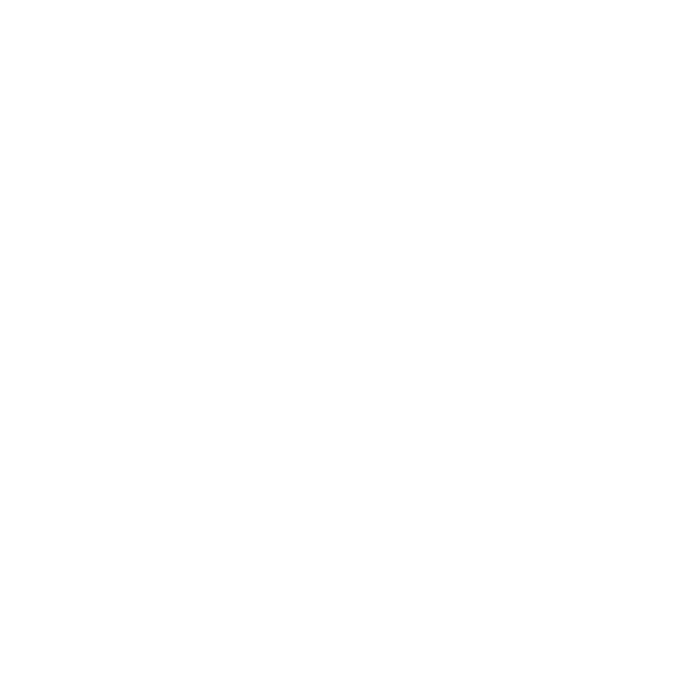

In [48]:
from IPython.display import Image
Image(f'{scenario_name}.gif')